<a href="https://colab.research.google.com/github/shoxruxmamitov/machine-learning1/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_LR.csv', index_col=0)
df.head(10)

,district,rooms,size,level,max_levels,price
0,Юнусабадский,3,57.0,4,4,52000.0
1,Яккасарайский,2,52.0,4,5,56000.0
2,Чиланзарский,2,42.0,4,4,37000.0
3,Чиланзарский,3,65.0,1,4,49500.0
4,Чиланзарский,3,70.0,3,5,55000.0
5,Чиланзарский,1,28.0,1,4,25500.0
6,Чиланзарский,1,30.0,2,4,21200.0
7,Яккасарайский,2,32.0,5,5,20000.0
8,Учтепинский,2,51.0,3,4,26200.0
9,Чиланзарский,1,30.0,1,4,22200.0


In [2]:
df['district'].value_counts()

,count
district,
Чиланзарский,1616
Мирзо-Улугбекский,1342
Учтепинский,872
Юнусабадский,847
Мирабадский,717
Яккасарайский,628
Яшнободский,456
Шайхантахурский,356
Олмазорский,262


In [3]:
housing = df[df.district=='Чиланзарский']
housing.head()

,district,rooms,size,level,max_levels,price
2,Чиланзарский,2,42.0,4,4,37000.0
3,Чиланзарский,3,65.0,1,4,49500.0
4,Чиланзарский,3,70.0,3,5,55000.0
5,Чиланзарский,1,28.0,1,4,25500.0
6,Чиланзарский,1,30.0,2,4,21200.0


In [4]:
X = housing['size'].to_numpy()
X

array([42., 65., 70., ..., 32., 70., 30.])

In [5]:
Y = housing['price'].to_numpy()
Y

array([37000., 49500., 55000., ..., 28000., 49800., 22914.])

Narx va uy maydoni o'rtasida chiziqli bog'liqlik bor ekanini tekshirib ko'ramiz.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

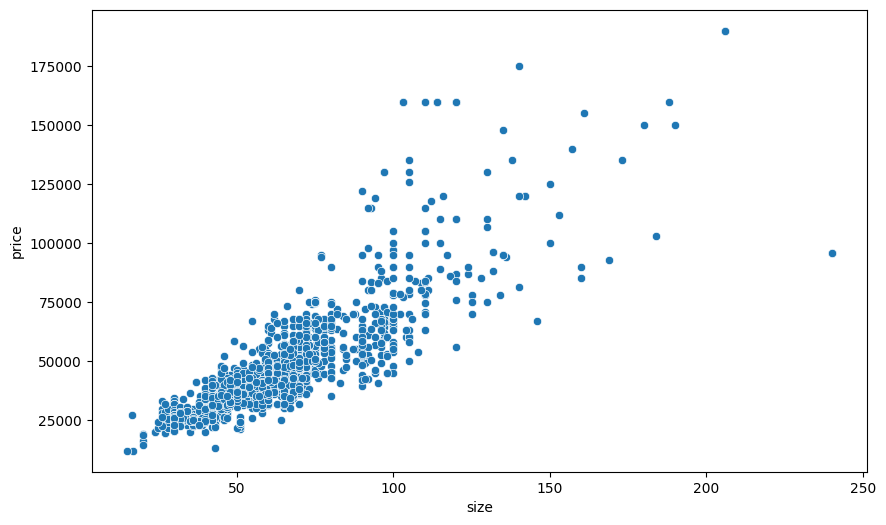

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=housing, x='size', y='price')
plt.show()

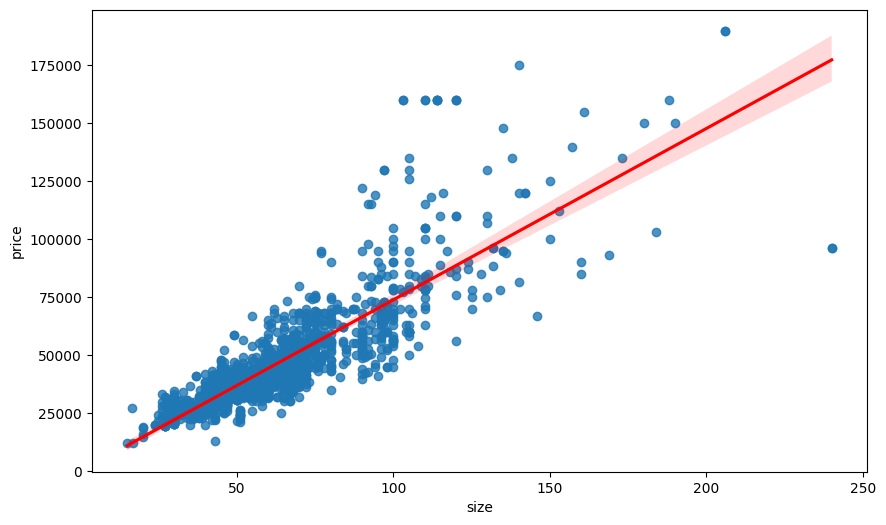

In [8]:
plt.figure(figsize=(10, 6))
sns.regplot(data=housing, x='size', y='price', line_kws={'color':'red'})
plt.show()

In [9]:
import numpy as np

In [10]:
xmean = np.mean(X)
ymean = np.mean(Y)
#  X va y o'zgaruvchilardan quyidagi formuladan foydalangan xolda  θ0  va  θ1  koeffisientlarni hisoblash.

In [11]:
theta1 = sum((X-xmean)*(Y-ymean))/sum((X-xmean)**2)
print(f'{theta1=}')

theta1=np.float64(740.0264822713287)


In [12]:
theta0 = ymean - theta1*xmean
print(f'{theta0=}')

theta0=np.float64(-195.94911352690542)


X dan bir nechta tasodifiy qiymatlarni ajratib olib va ularga mos keluvchi y ni yuqoridagi koeffisientlar yordamida hisoblab ko'rdik

In [13]:
x_test = housing.sample(10, random_state=42)['size'].to_numpy()
print(f'{x_test=}')

x_test=array([54., 42., 36., 60., 48., 68., 38., 65., 52., 44.])


In [14]:
y_test = housing.sample(10, random_state=42)['price'].to_numpy()
print(f'{y_test=}')

y_test=array([37500., 26500., 25500., 39000., 32500., 34500., 22700., 47000.,
       37900., 36000.])


Hisoblangan va asl qiymtlar o'rtasidagi RMSE (root mean square error), MAE (mean absolute error) hisobladik

In [15]:
MAE = np.sum(abs(y_test-theta0-theta1*x_test))/len(x_test)
MAE

np.float64(4140.35031634715)

In [16]:
RMSE = np.sqrt(np.sum((y_test-theta0-theta1*x_test)**2)/len(x_test))
RMSE

np.float64(5882.051673173715)